# EDA - Inventory Table

## Setup

In [1]:
import sys
sys.path.append('../')

import polars as pl

import seaborn as sns
import matplotlib.pyplot as plt

from sqlalchemy import create_engine, URL
from utils.db_connection import connection_info

In [2]:
url = URL.create(
    drivername=connection_info['drivername'],
    username=connection_info['username'],
    password=connection_info['password'],
    host=connection_info['host'],
    port=connection_info['port'],
    database="retail"
)

engine = create_engine(url)

conn = engine.connect()

# SELECT * is a horrible idea in production, so I'm splitting up into 3 separate queries based on what type of data they have contained 
# Categorical data, numeric data, and datetime data
categorical_only = pl.read_database(
    query="""
        SELECT 
            sku,
            product_name,
            category,
            store_location,
            supplier_name,
            markdown_flag
        FROM inventory
    """,
    connection=conn
)

numeric_only = pl.read_database(
    query="""
        SELECT 
            units_on_hand,
            reorder_point,
            days_on_shelf,
            unit_cost_usd,
            unit_retail_price_usd,
            out_of_stock_days_30d
        FROM inventory
    """,
    connection=conn
)

datetime_only = pl.read_database(
    query="""
        SELECT 
            last_restock_date,
            expiry_date
        FROM inventory
    """,
    connection=conn
)

conn.close()

## Verification

Get a little bit of an overview of the data with looking at the first 10 rows and seeing the null counts to see what we're dealing with.

In [3]:
categorical_only.head(10)

sku,product_name,category,store_location,supplier_name,markdown_flag
str,str,str,str,str,str
"""SKU-1102""","""Cherry Tomatoes 10oz Pint""","""Produce""","""Soth Main St""","""Sunrise Grocery Supply""","""No"""
"""SKU-1184""","""Winston Red Box 20ct""","""Tobacco""","""Soth Corner""","""HEARTLAND DISTRIBUTION""","""Yes"""
"""SKU-1161""","""Oral-B Soft Toothbrush 2ct""","""Personal Care""","""South Plaza""","""heartland distribution""","""n"""
"""SKU-1074""","""Hot Pockets Ham Cheese 9oz""","""Frozen""","""North Plaza""","""QUICKSHIP WHOLESALE""","""n"""
"""SKU-1212""","""Anker PowerCore 10000mAh Power…","""Electronics""","""WEST Corner""","""FRESHFARM CO""","""Y"""
"""SKU-1148""","""Reynolds Wrap Aluminum Foil 75…","""Household""","""North Corner""","""Freshfarm co""","""N"""
"""SKU-1130""","""Land O'Frost Deli Ham 16oz""","""Meat""","""East Plaza""","""QUICKSHIP WHOLESALE""","""Y"""
"""SKU-1107""","""Cucumber Each""","""Produce""","""West Main St""","""FreshFarm Co""","""y"""
"""SKU-1053""","""Land O'Lakes Butter 1lb""","""Dairy""","""East Plaza""","""pacific coast foods""","""0"""


In [4]:
categorical_only.null_count()

sku,product_name,category,store_location,supplier_name,markdown_flag
u32,u32,u32,u32,u32,u32
0,0,0,0,0,0


So far, there's a little bit of messy data in the markdown flag and the supplier name columns. Worth investigating later as I might have to clean it all up in the transformation layer.

In [5]:
numeric_only.head(10)

units_on_hand,reorder_point,days_on_shelf,unit_cost_usd,unit_retail_price_usd,out_of_stock_days_30d
i64,i64,i64,"decimal[38,2]","decimal[38,2]",i64
69,11,8,14.39,26.09,1
111,5,37,8.35,2.08,0
8,23,-1,6.28,0.77,0
2,49,1,2.21,16.40,0
8,33,26,4.47,17.16,2
4,34,8,10.32,14.39,1
20,13,9,7.40,5.76,0
89,17,9,0.74,2.64,1
52,5,28,3.96,11.72,0


In [6]:
numeric_only.null_count()

units_on_hand,reorder_point,days_on_shelf,unit_cost_usd,unit_retail_price_usd,out_of_stock_days_30d
u32,u32,u32,u32,u32,u32
0,0,0,0,0,0


In [7]:
datetime_only.head(10)

last_restock_date,expiry_date
str,str
"""2023-11-28 01:48:32""","""2026-02-22"""
"""2023-10-22 10:27:13""",null
"""2023-04-02 09:16:12""",null
"""2023-12-17 04:35:13""","""2024-10-02"""
"""2023-01-26 19:44:49""",null
"""2023-03-12 19:26:39""",null
"""2023-11-23 20:51:10""","""2025-03-03"""
"""2023-05-22 06:31:36""","""2025-01-09"""
"""2024-05-04 09:42:19""","""2025-12-27"""


In [8]:
datetime_only.null_count()

last_restock_date,expiry_date
u32,u32
0,10695


There's a lot of nulls in the expiry date column. Interesting. Could it be that certain products have an expiry data while others don't? Worth investigating later.

Now, what about duplicate rows?

In [9]:
full_df = categorical_only.with_columns(
    numeric_only.select('*')
).with_columns(datetime_only.select('*'))

full_df

sku,product_name,category,store_location,supplier_name,markdown_flag,units_on_hand,reorder_point,days_on_shelf,unit_cost_usd,unit_retail_price_usd,out_of_stock_days_30d,last_restock_date,expiry_date
str,str,str,str,str,str,i64,i64,i64,"decimal[38,2]","decimal[38,2]",i64,str,str
"""SKU-1102""","""Cherry Tomatoes 10oz Pint""","""Produce""","""Soth Main St""","""Sunrise Grocery Supply""","""No""",69,11,8,14.39,26.09,1,"""2023-11-28 01:48:32""","""2026-02-22"""
"""SKU-1184""","""Winston Red Box 20ct""","""Tobacco""","""Soth Corner""","""HEARTLAND DISTRIBUTION""","""Yes""",111,5,37,8.35,2.08,0,"""2023-10-22 10:27:13""",null
"""SKU-1161""","""Oral-B Soft Toothbrush 2ct""","""Personal Care""","""South Plaza""","""heartland distribution""","""n""",8,23,-1,6.28,0.77,0,"""2023-04-02 09:16:12""",null
"""SKU-1074""","""Hot Pockets Ham Cheese 9oz""","""Frozen""","""North Plaza""","""QUICKSHIP WHOLESALE""","""n""",2,49,1,2.21,16.40,0,"""2023-12-17 04:35:13""","""2024-10-02"""
"""SKU-1212""","""Anker PowerCore 10000mAh Power…","""Electronics""","""WEST Corner""","""FRESHFARM CO""","""Y""",8,33,26,4.47,17.16,2,"""2023-01-26 19:44:49""",null
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""SKU-1000""","""Coca-Cola 20oz""","""Beverages""","""North Plaza""","""Freshfarm co""","""Y""",64,32,4,16.47,7.11,3,"""2024-11-29 03:20:10""","""2024-07-30"""
"""SKU-1147""","""Ziploc Gallon Storage Bags 19c…","""Household""","""East Corner""","""Metro foods LLC""","""N""",25,28,2,2.56,0.81,4,"""2024-05-11 08:20:14""",null
"""SKU-1198""","""Cash4Life $2 Ticket""","""Lottery""","""North Plaza""","""QUICKSHIP WHOLESALE""","""n""",6,16,9,11.22,9.55,0,"""2023-06-13 08:30:18""",null


In [10]:
full_df.is_duplicated().value_counts()

,count
bool,u32
false,40000


Doesn't look like there's any duplicate rows so far. However, the data is messy and it might mess around with the calculations, so, once it's entirely cleaned I'll investigate later.

## Categorical

Let's check the SKUs and their respective products to see if there's some SKUs that might be duplicated.

In [11]:
sku_product_combos = categorical_only.select(
    pl.col('sku'),
    pl.col('product_name')
).unique().sort('sku')

sku_product_combos

sku,product_name
str,str
"""SKU-1000""","""Coca-Cola 20oz"""
"""SKU-1001""","""Pepsi 20oz"""
"""SKU-1002""","""Dr Pepper 20oz"""
"""SKU-1003""","""Sprite 20oz"""
"""SKU-1004""","""Mountain Dew 20oz"""
…,…
"""SKU-1217""","""Skullcandy Jib Wireless Earbud…"
"""SKU-1218""","""Belkin 3-Outlet Surge Protecto…"
"""SKU-1219""","""Philips Hue White A19 Bulb 2ct"""


C:\Users\Peti Vlaskovits\AppData\Local\Temp\ipykernel_19524\2663833408.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax = ax.set_yticklabels(labels=ax.get_yticklabels(), fontsize=3)


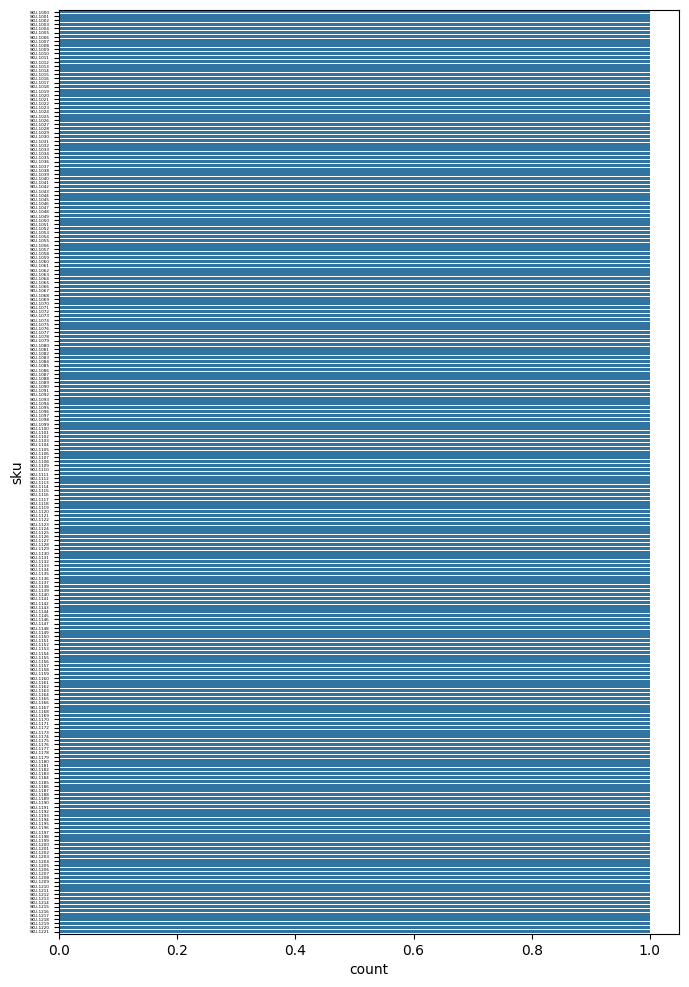

In [12]:
fig, ax = plt.subplots(figsize=(8, 12))
sns.countplot(data=sku_product_combos.to_pandas(), y='sku', ax=ax)
ax = ax.set_yticklabels(labels=ax.get_yticklabels(), fontsize=3)

Nothing suspicious so far. What about the categories?

In [13]:
categorical_only.select(
    pl.col("category")
).unique().sort('category', descending=False)

category
str
"""BAKERY"""
"""BEVERAGES"""
"""Bakery"""
"""Bakrey"""
"""Beverages"""
…
"""meat"""
"""personal care"""
"""produce"""


Looks like I need to clean up the categories and make them all consistent with plenty of cleaning in the transformation layer.
What about the store names?

In [14]:
categorical_only.select(
    pl.col("store_location")
).unique().sort('store_location', descending=False)

store_location
str
"""EAST Corner"""
"""EAST Main St"""
"""EAST Plaza"""
"""Eas Corner"""
"""Eas Main St"""
…
"""south Main St"""
"""south Plaza"""
"""west Corner"""


Notice a pattern here?

In [15]:
categorical_only.select(
    pl.col("supplier_name")
).unique().sort('supplier_name', descending=False)

supplier_name
str
"""FRESHFARM CO"""
"""FreshFarm Co"""
"""Freshfarm co"""
"""HEARTLAND DISTRIBUTION"""
"""Heartland Distribution"""
…
"""metro foods llc"""
"""national beverage dist"""
"""pacific coast foods"""


In [16]:
categorical_only.select(
    pl.col("markdown_flag")
).unique().sort('markdown_flag', descending=False)

markdown_flag
str
"""0"""
"""1"""
"""FALSE"""
"""N"""
"""No"""
"""TRUE"""
"""Y"""
"""Yes"""
"""n"""


There's a lot of typos and there are plenty of cases where it's between upper and lower case across the product categories, the stores, and the suppliers.

The markdown flag needs to be cleaned as well with all the inconsistent formatting.


### Plan

I need to make the markdown flag be more consistent by mapping some values into something like ("TRUE", "FALSE"). That's easy.

However, for the other messy columns, they need to be in all uppercase first, then I could either:
1. Manually map out typos to corrections
2. Automate spellchecking
3. Hybrid approach (mapping + spellchecking)

I found this [package](https://github.com/filyp/autocorrect) that could help us automate spellchecking...

I'd say a hybrid approach works best, but it has to be selectively used on some columns, while for other columns, they need to be manually mapped to. That being said I have to implement data quality checks in the pipeline in order to catch new typos in a production environment. Plus, neither are perfect solutions - automating spellchecking entirely means trusting the output, but it's not perfect, and manually mapping out typos to corrections is manual and gets tiring for data engineers, who could be doing more productive things aside from controlling which typos go into which corrections.

## Numerical

Let's get some summary statistics and visualize the data as well.

In [17]:
numeric_only.describe()

statistic,units_on_hand,reorder_point,days_on_shelf,unit_cost_usd,unit_retail_price_usd,out_of_stock_days_30d
str,f64,f64,f64,f64,f64,f64
"""count""",40000.0,40000.0,40000.0,40000.0,40000.0,40000.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",59.92795,25.1863,23.0372,7.15217,10.724497,1.999375
"""std""",84.866494,20.117104,24.790004,6.493045,10.034413,2.699362
"""min""",-10.0,5.0,-1.0,0.44,0.5,0.0
"""25%""",12.0,12.0,5.0,2.38,4.04,0.0
"""50%""",30.0,20.0,15.0,5.01,7.44,1.0
"""75%""",71.0,32.0,33.0,9.41,13.62,3.0
"""max""",500.0,200.0,180.0,30.0,49.99,27.0


Every column is skewed to the right... plus, there's negative units on hand and negative days on the shelf as well. This is worth investigating.

In [18]:
full_df.filter(
    pl.col('units_on_hand') < 1
)

sku,product_name,category,store_location,supplier_name,markdown_flag,units_on_hand,reorder_point,days_on_shelf,unit_cost_usd,unit_retail_price_usd,out_of_stock_days_30d,last_restock_date,expiry_date
str,str,str,str,str,str,i64,i64,i64,"decimal[38,2]","decimal[38,2]",i64,str,str
"""SKU-1104""","""Russet Potatoes 5lb Bag""","""Produce""","""North Plaza""","""Pacific Coast Foods""","""Yes""",-4,43,17,1.51,5.90,2,"""2023-05-14 10:07:34""","""2024-09-08"""
"""SKU-1132""","""Oscar Mayer Deli Fresh Chicken…","""Meat""","""North Main St""","""Heartland Distribution""","""N""",-10,5,34,1.94,8.45,0,"""2024-01-05 06:44:36""","""2024-11-27"""
"""SKU-1046""","""Nature Valley Oats Honey Bar 1…","""Snacks""","""North Main St""","""pacific coast foods""","""n""",-6,29,10,13.83,3.44,3,"""2023-06-29 03:08:50""","""2026-05-08"""
"""SKU-1138""","""Spam Classic 12oz""","""Meat""","""West Main St""","""pacific coast foods""","""Yes""",-1,71,63,15.16,8.95,0,"""2024-03-18 03:49:28""","""2024-11-22"""
"""SKU-1184""","""Winston Red Box 20ct""","""Tobacco""","""North Corner""","""pacific coast foods""","""Yes""",-1,44,11,8.35,1.20,4,"""2024-04-16 07:46:54""",null
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""SKU-1054""","""Kerrygold Unsalted Butter 8oz""","""Dairy""","""North Corner""","""PACIFIC COAST FOODS""","""Y""",-5,49,4,2.38,6.05,0,"""2024-07-18 05:52:50""","""2025-12-21"""
"""SKU-1153""","""Dawn Ultra Original Dish Soap …","""Household""","""East Plaza""","""quickship wholesale""","""0""",-4,7,37,1.60,6.53,5,"""2023-03-26 13:44:57""",null
"""SKU-1156""","""Lysol Disinfecting Spray 19oz""","""Household""","""North Plaza""","""metro foods llc""","""N""",0,12,2,3.52,39.57,3,"""2023-02-12 21:12:03""",null


In [19]:
full_df.filter(
    pl.col('days_on_shelf') < 1
)

sku,product_name,category,store_location,supplier_name,markdown_flag,units_on_hand,reorder_point,days_on_shelf,unit_cost_usd,unit_retail_price_usd,out_of_stock_days_30d,last_restock_date,expiry_date
str,str,str,str,str,str,i64,i64,i64,"decimal[38,2]","decimal[38,2]",i64,str,str
"""SKU-1161""","""Oral-B Soft Toothbrush 2ct""","""Personal Care""","""South Plaza""","""heartland distribution""","""n""",8,23,-1,6.28,0.77,0,"""2023-04-02 09:16:12""",null
"""SKU-1037""","""Wheat Thins Original 9.1oz""","""Snacks""","""South Corner""","""FreshFarm Co""","""0""",24,22,-1,6.65,17.40,1,"""2023-04-19 23:38:28""","""2026-03-06"""
"""SKU-1080""","""Ore-Ida Golden Crinkles 32oz""","""Frozen""","""North Corner""","""Metro foods LLC""","""TRUE""",10,12,-1,11.78,2.47,0,"""2024-09-21 23:19:38""","""2024-08-30"""
"""SKU-1203""","""$20 Scratch-Off Ticket""","""Lottery""","""West Plaza""","""QuickShip Wholesale""","""Y""",284,12,-1,6.07,7.11,1,"""2024-05-05 12:19:13""",null
"""SKU-1012""","""5-hour Energy Berry 1.93oz""","""Beverages""","""South Corner""","""Pacific Coast Foods""","""0""",12,13,-1,2.29,15.91,3,"""2024-05-02 01:50:59""","""2026-01-16"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""SKU-1169""","""Pantene Smooth & Sleek Shampoo…","""Personal Care""","""North Corner""","""QUICKSHIP WHOLESALE""","""N""",8,7,-1,6.42,2.29,0,"""2024-02-27 06:01:12""","""2024-06-27"""
"""SKU-1044""","""Skittles Original 2.17oz""","""Snacks""","""North Plaza""","""sunrise grocery supply""","""No""",51,24,-1,20.99,3.65,0,"""2024-07-10 20:37:26""","""2024-08-04"""
"""SKU-1148""","""Reynolds Wrap Aluminum Foil 75…","""Household""","""North Plaza""","""National Beverage Dist""","""Y""",251,11,-1,10.32,7.87,0,"""N/A""",null


Looks like there's a few goods received note mismatches and some of the days on shelf that a product has left is unknown (-1).

<Axes: xlabel='units_on_hand', ylabel='Count'>

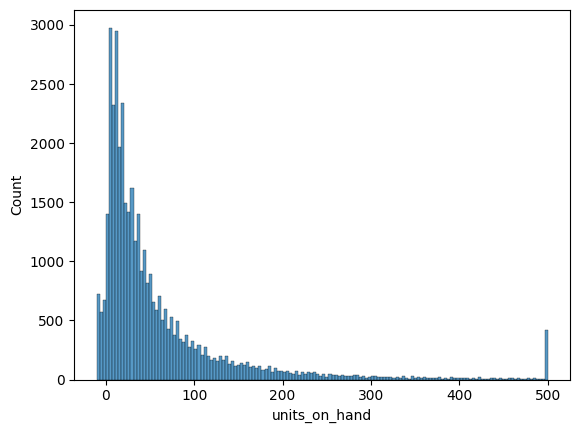

In [20]:
sns.histplot(data=numeric_only.to_pandas(), x='units_on_hand')

<Axes: xlabel='units_on_hand'>

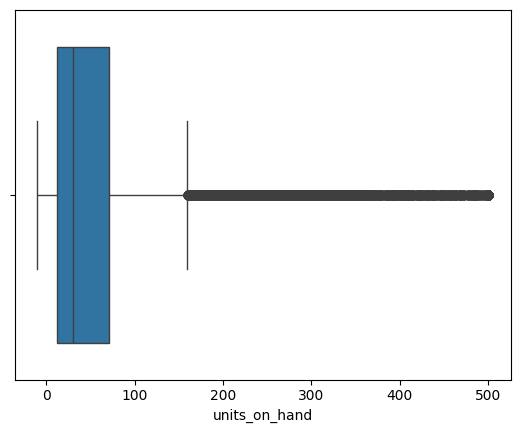

In [21]:
sns.boxplot(data=numeric_only.to_pandas(), x='units_on_hand')

<Axes: xlabel='reorder_point', ylabel='Count'>

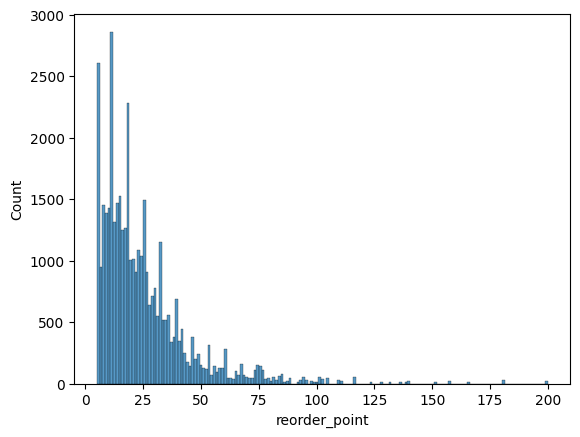

In [22]:
sns.histplot(data=numeric_only.to_pandas(), x='reorder_point')

<Axes: xlabel='reorder_point'>

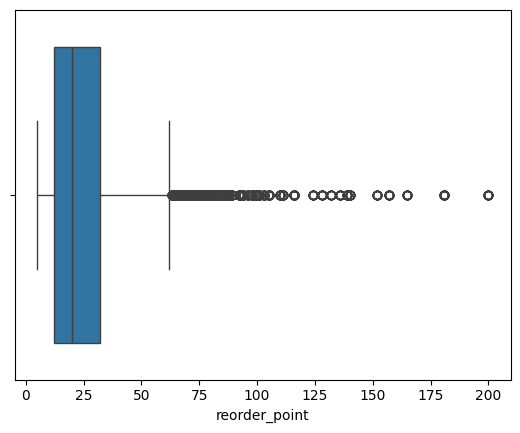

In [23]:
sns.boxplot(data=numeric_only.to_pandas(), x='reorder_point')

<Axes: xlabel='days_on_shelf', ylabel='Count'>

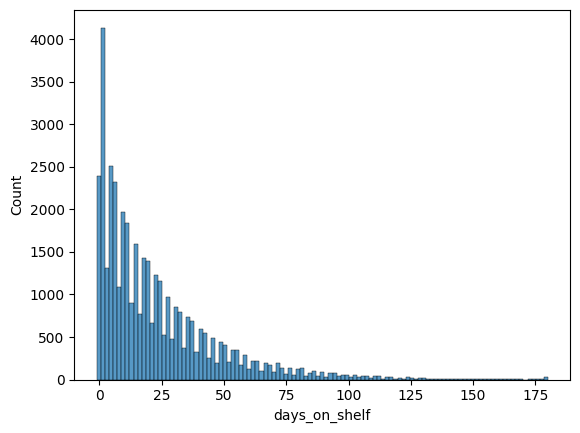

In [24]:
sns.histplot(data=numeric_only.to_pandas(), x='days_on_shelf')

<Axes: xlabel='days_on_shelf'>

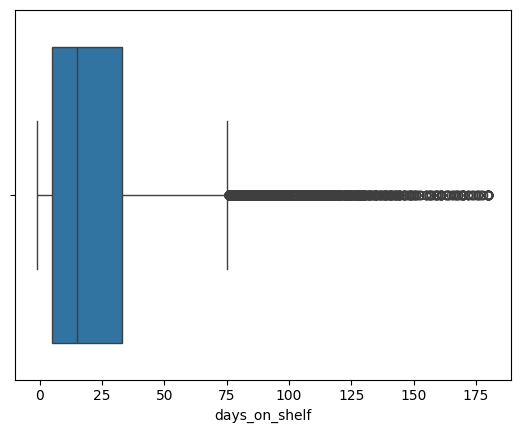

In [25]:
sns.boxplot(data=numeric_only.to_pandas(), x='days_on_shelf')

<Axes: xlabel='unit_retail_price_usd', ylabel='Count'>

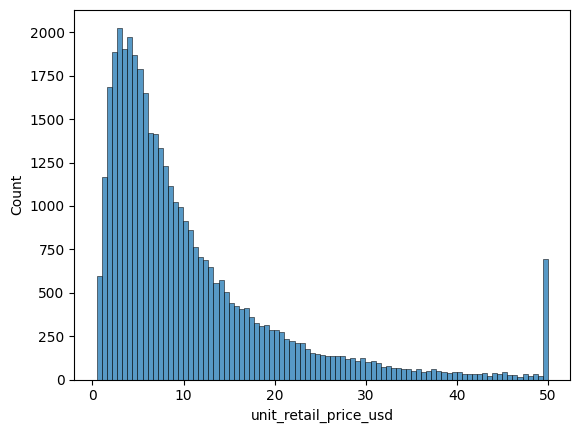

In [26]:
sns.histplot(data=numeric_only.to_pandas(), x='unit_retail_price_usd')

<Axes: xlabel='unit_retail_price_usd'>

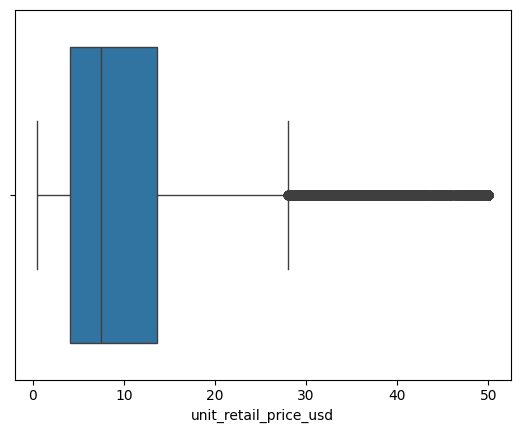

In [27]:
sns.boxplot(data=numeric_only.to_pandas(), x='unit_retail_price_usd')

<Axes: xlabel='out_of_stock_days_30d', ylabel='Count'>

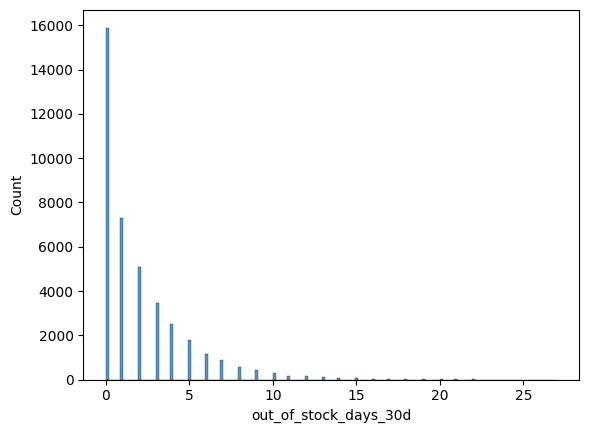

In [28]:
sns.histplot(data=numeric_only.to_pandas(), x='out_of_stock_days_30d')

<Axes: xlabel='out_of_stock_days_30d'>

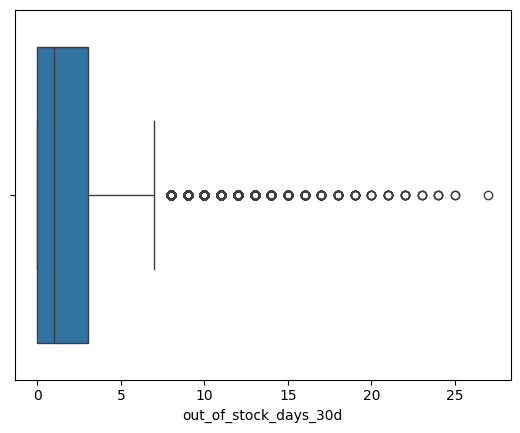

In [29]:
sns.boxplot(data=numeric_only.to_pandas(), x='out_of_stock_days_30d')

Pretty much every column except out_of_stock_days_30d is continuous. Plus, there are a few columns that have spikes at the maximum value, but that's because of how Claude generated the data. IRL there wouldn't be spikes and the range would be larger. 

## Datetimes

Let's derive the columns first and extract everything that we can that might be useful.

In [30]:
restock_derived = datetime_only.select(pl.col('last_restock_date').str.to_datetime(strict=False))
expired_derived = datetime_only.select(pl.col('expiry_date').str.to_date(strict=False))

In [31]:
restock_derived

last_restock_date
datetime[μs]
2023-11-28 01:48:32
2023-10-22 10:27:13
2023-04-02 09:16:12
2023-12-17 04:35:13
2023-01-26 19:44:49
…
2024-11-29 03:20:10
2024-05-11 08:20:14
2023-06-13 08:30:18


In [32]:
expired_derived

expiry_date
date
2026-02-22
null
null
2024-10-02
null
…
2024-07-30
null
null


In [33]:
restock_derived.null_count()

last_restock_date
u32
2033


Hmm... plenty of nulls there after converting to datetime. Let's check the original data to find out what made this happen.

In [34]:
datetime_only.select(pl.col('last_restock_date').value_counts()).unnest(columns='last_restock_date').sort(by='count', descending=True)

last_restock_date,count
str,u32
"""N/A""",528
"""TBD""",527
"""??""",520
"""""",458
"""2023-12-10 06:33:41""",2
…,…
"""2023-03-07 03:33:52""",1
"""2024-05-13 15:02:08""",1
"""2023-11-15 09:57:56""",1


Interesting... there's a couple data quality issues there. I might just filter these out by converting them to nulls then filtering out the nulls themselves. Plus, I should enforce data quality and make sure that this column is a datetime column after it gets converted into one. Sure, you lose data, but... I can't really impute the data here, and I don't want to mess up KPI calculations relating to this, so I have no other choice than to filter this out.

Now let's check out the expiration date issue as well.

In [35]:
datetime_only.with_columns(
    categorical_only.select(pl.col('sku'), pl.col('product_name'))
).drop('last_restock_date').filter(pl.col('expiry_date').is_null())

expiry_date,sku,product_name
str,str,str
null,"""SKU-1184""","""Winston Red Box 20ct"""
null,"""SKU-1161""","""Oral-B Soft Toothbrush 2ct"""
null,"""SKU-1212""","""Anker PowerCore 10000mAh Power…"
null,"""SKU-1148""","""Reynolds Wrap Aluminum Foil 75…"
null,"""SKU-1211""","""AmazonBasics USB-A to USB-C Ca…"
…,…,…
null,"""SKU-1161""","""Oral-B Soft Toothbrush 2ct"""
null,"""SKU-1158""","""Mr. Clean Original Multi-Surfa…"
null,"""SKU-1147""","""Ziploc Gallon Storage Bags 19c…"


It's normal. Certain products don't have expiration dates at the end of the day. Let's impute the column with "N/A" for all null values within this column so that we can make it clearer for data analysts to work with when doing their analysis.

Next step: Go through all of the derived columns! But first, let's filter out all of the nulls.

In [36]:
expired_derived = expired_derived.select(pl.col('expiry_date')).filter(pl.col('expiry_date').is_not_null() == True)
restock_derived = restock_derived.select(pl.col('last_restock_date')).filter(pl.col('last_restock_date').is_not_null() == True)

In [37]:
expired_derived

expiry_date
date
2026-02-22
2024-10-02
2025-03-03
2025-01-09
2025-12-27
…
2025-02-26
2025-03-30
2025-06-06


In [38]:
restock_derived

last_restock_date
datetime[μs]
2023-11-28 01:48:32
2023-10-22 10:27:13
2023-04-02 09:16:12
2023-12-17 04:35:13
2023-01-26 19:44:49
…
2024-11-29 03:20:10
2024-05-11 08:20:14
2023-06-13 08:30:18


In [39]:
expired_derived = expired_derived.select(
    pl.col('expiry_date').dt.year().alias('year'),
    pl.col('expiry_date').dt.month().alias('month'),
    pl.col('expiry_date').dt.day().alias('day'),
    pl.col('expiry_date').dt.quarter().alias('quarter'),
    pl.col('expiry_date').dt.week().alias('week'),
    pl.col('expiry_date').dt.weekday().alias('weekday')
)

expired_derived

year,month,day,quarter,week,weekday
i32,i8,i8,i8,i8,i8
2026,2,22,1,8,7
2024,10,2,4,40,3
2025,3,3,1,10,1
2025,1,9,1,2,4
2025,12,27,4,52,6
…,…,…,…,…,…
2025,2,26,1,9,3
2025,3,30,1,13,7
2025,6,6,2,23,5


In [40]:
restock_derived = restock_derived.select(
    pl.col('last_restock_date').dt.year().alias('year'),
    pl.col('last_restock_date').dt.month().alias('month'),
    pl.col('last_restock_date').dt.day().alias('day'),
    pl.col('last_restock_date').dt.quarter().alias('quarter'),
    pl.col('last_restock_date').dt.week().alias('week'),
    pl.col('last_restock_date').dt.weekday().alias('weekday'),
    pl.col('last_restock_date').dt.hour().alias('hour'),
    pl.col('last_restock_date').dt.minute().alias('minute'),
    pl.col('last_restock_date').dt.second().alias('second')
)

restock_derived

year,month,day,quarter,week,weekday,hour,minute,second
i32,i8,i8,i8,i8,i8,i8,i8,i8
2023,11,28,4,48,2,1,48,32
2023,10,22,4,42,7,10,27,13
2023,4,2,2,13,7,9,16,12
2023,12,17,4,50,7,4,35,13
2023,1,26,1,4,4,19,44,49
…,…,…,…,…,…,…,…,…
2024,11,29,4,48,5,3,20,10
2024,5,11,2,19,6,8,20,14
2023,6,13,2,24,2,8,30,18


Summary statistics!

In [41]:
expired_derived.describe()

statistic,year,month,day,quarter,week,weekday
str,f64,f64,f64,f64,f64,f64
"""count""",29305.0,29305.0,29305.0,29305.0,29305.0,29305.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",2024.909776,6.551919,15.69193,2.516635,26.608702,3.997099
"""std""",0.701376,3.446796,8.805154,1.118433,14.977511,2.001848
"""min""",2024.0,1.0,1.0,1.0,1.0,1.0
"""25%""",2024.0,4.0,8.0,2.0,14.0,2.0
"""50%""",2025.0,7.0,16.0,3.0,27.0,4.0
"""75%""",2025.0,10.0,23.0,4.0,40.0,6.0
"""max""",2026.0,12.0,31.0,4.0,52.0,7.0


In [42]:
restock_derived.describe()

statistic,year,month,day,quarter,week,weekday,hour,minute,second
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",37967.0,37967.0,37967.0,37967.0,37967.0,37967.0,37967.0,37967.0,37967.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",2023.503964,6.537098,15.835857,2.51234,26.604657,4.004372,11.500303,29.563621,29.388838
"""std""",0.499991,3.445948,8.779251,1.116696,15.051696,2.00097,6.940297,17.312929,17.365119
"""min""",2023.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
"""25%""",2023.0,4.0,8.0,2.0,14.0,2.0,5.0,15.0,14.0
"""50%""",2024.0,7.0,16.0,3.0,27.0,4.0,12.0,30.0,29.0
"""75%""",2024.0,10.0,23.0,4.0,40.0,6.0,18.0,45.0,44.0
"""max""",2024.0,12.0,31.0,4.0,52.0,7.0,23.0,59.0,59.0


Hmmm... a little bit of skewness across both columns. And they're both very similar...